<a href="https://colab.research.google.com/github/SRET-College/Sem-6-NN-and-DL/blob/main/NN_and_DL_Expt_6_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Expt 6.2 - Implement CNN by downloading dataset from Kaggle

In [ ]:
!nvidia-smi

Tue Apr  7 16:08:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("New dataset downloaded to:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
New dataset downloaded to: /kaggle/input/intel-image-classification


In [ ]:
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir = os.path.join(path, "seg_test/seg_test")

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
model = Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model Summary")
model.summary()
print("Model Defined and Compiled Successfully")

Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

Model Defined and Compiled Successfully


In [ ]:
history = model.fit(train_generator, epochs=10, validation_data=test_generator)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 379ms/step - accuracy: 0.6042 - loss: 1.0197 - val_accuracy: 0.6653 - val_loss: 0.9244
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 94s 213ms/step - accuracy: 0.7418 - loss: 0.7055 - val_accuracy: 0.7937 - val_loss: 0.5798
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 99s 225ms/step - accuracy: 0.7878 - loss: 0.5930 - val_accuracy: 0.8193 - val_loss: 0.5206
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 95s 217ms/step - accuracy: 0.8135 - loss: 0.5251 - val_accuracy: 0.8027 - val_loss: 0.5613
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 95s 217ms/step - accuracy: 0.8292 - loss: 0.4750 - val_accuracy: 0.8240 - val_loss: 0.4904
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 94s 214ms/step - accuracy: 0.8453 - loss: 0.4381 - val_accuracy: 0.7923 - val_loss: 0.6267
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 92s 210ms/step - accuracy: 0.8504 - loss: 0.4125 - val_accuracy: 0.8517 - val_loss: 0.4344
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 93s 211ms/step - accuracy: 0.8595 - loss: 

In [ ]:
print("Evaluating model performance...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating model performance...
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8510 - loss: 0.4609
Test Loss: 0.4609
Test Accuracy: 0.8510


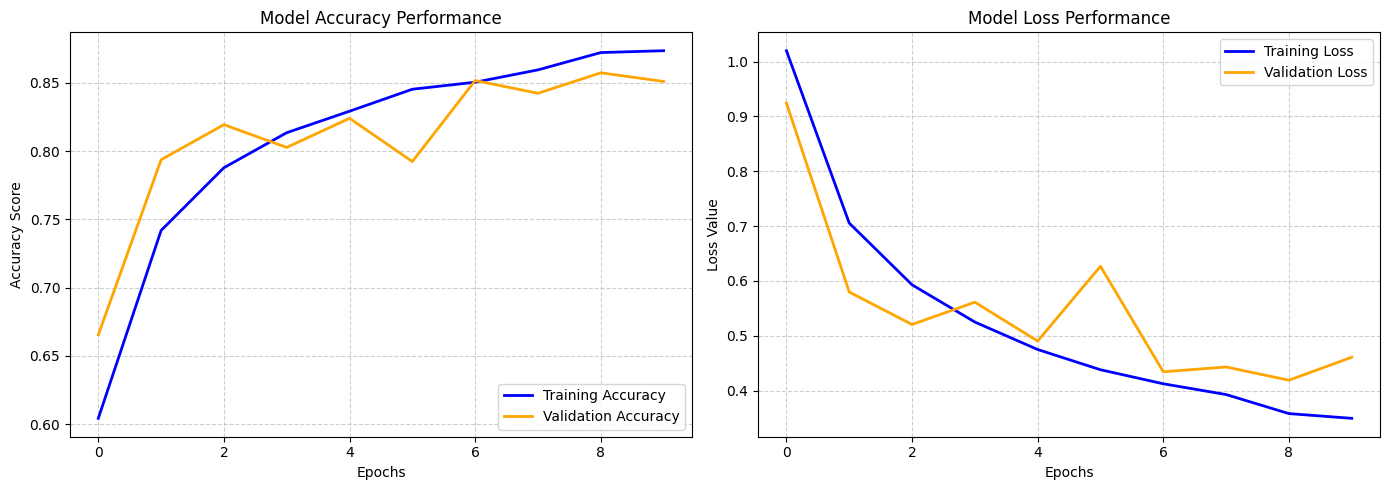

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()